In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\GUVI REPO\clickstream_data_analysis\clickstream+data+for+online+shopping\e-shop clothing 2008.csv", sep=";", engine="python")

In [3]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

year                       0
month                      0
day                        0
order                      0
country                    0
session ID                 0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64

In [7]:
df.columns = df.columns.str.replace(" ","_").str.replace("(","").str.replace(")","").str.lower()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   year                   165474 non-null  int64 
 1   month                  165474 non-null  int64 
 2   day                    165474 non-null  int64 
 3   order                  165474 non-null  int64 
 4   country                165474 non-null  int64 
 5   session_id             165474 non-null  int64 
 6   page_1_main_category   165474 non-null  int64 
 7   page_2_clothing_model  165474 non-null  object
 8   colour                 165474 non-null  int64 
 9   location               165474 non-null  int64 
 10  model_photography      165474 non-null  int64 
 11  price                  165474 non-null  int64 
 12  price_2                165474 non-null  int64 
 13  page                   165474 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 17.7+ MB


In [9]:
for col in df.columns:
    print(f"Column Name:{col}")
    print(f"Column Count:{df[col].nunique()}")
    print(f"Unique values:{df[col].unique()}")

Column Name:year
Column Count:1
Unique values:[2008]
Column Name:month
Column Count:5
Unique values:[4 5 6 7 8]
Column Name:day
Column Count:31
Unique values:[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
Column Name:order
Column Count:195
Unique values:[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172

In [10]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [11]:
df["date"] = pd.to_datetime(df[["year","month","day"]])

In [12]:
df['day_of_week'] = df["date"].dt.dayofweek

In [13]:
df["weekday_name"] = df["date"].dt.day_name()

In [14]:
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [15]:
df["week_of_year"] = df["date"].dt.isocalendar().week

In [16]:
df["quarter"] = df["date"].dt.quarter

In [17]:
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

In [18]:
import numpy as np

df["month_sin"] = np.sin(2 * np.pi * df['month']/12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]/12)

df['dayofweek_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

In [19]:
import sys
!{sys.executable} -m pip install holidays

In [20]:
import holidays

ind_holidays = holidays.India(years=[2008])

df["is_holiday"] = df["date"].isin(ind_holidays).astype(int)

C:\Users\KaneshKumar\AppData\Local\Temp\ipykernel_27132\3284041955.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_holiday"] = df["date"].isin(ind_holidays).astype(int)


In [21]:
def classify_order(order):
    if order <=40:
        return "Low"
    elif order <=100:
        return "Medium"
    elif order <=170:
        return "High"
    elif order <=200:
        return "Very_high"

In [22]:
df["order_level"] = df["order"].apply(classify_order)

In [23]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,week_of_year,quarter,is_month_start,is_month_end,month_sin,month_cos,dayofweek_sin,dayofweek_cos,is_holiday,order_level
0,2008,4,1,1,29,1,1,A13,1,5,...,14,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low
1,2008,4,1,2,29,1,1,A16,1,6,...,14,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low
2,2008,4,1,3,29,1,2,B4,10,2,...,14,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low
3,2008,4,1,4,29,1,2,B17,6,6,...,14,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low
4,2008,4,1,5,29,1,2,B8,4,3,...,14,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low


In [24]:
country_map = {
    1: "Australia",
    2: "Austria",
    3: "Belgium",
    4: "British Virgin Islands",
    5: "Cayman Islands",
    6: "Christmas Island",
    7: "Croatia",
    8: "Cyprus",
    9: "Czech Republic",
    10: "Denmark",
    11: "Estonia",
    12: "unidentified",
    13: "Faroe Islands",
    14: "Finland",
    15: "France",
    16: "Germany",
    17: "Greece",
    18: "Hungary",
    19: "Iceland",
    20: "India",
    21: "Ireland",
    22: "Italy",
    23: "Latvia",
    24: "Lithuania",
    25: "Luxembourg",
    26: "Mexico",
    27: "Netherlands",
    28: "Norway",
    29: "Poland",
    30: "Portugal",
    31: "Romania",
    32: "Russia",
    33: "San Marino",
    34: "Slovakia",
    35: "Slovenia",
    36: "Spain",
    37: "Sweden",
    38: "Switzerland",
    39: "Ukraine",
    40: "United Arab Emirates",
    41: "United Kingdom",
    42: "USA",
    43: "biz (.biz)",
    44: "com (.com)",
    45: "int (.int)",
    46: "net (.net)",
    47: "org (*.org)"
}
order_level_map ={
    "Low":0,
    "Medium":1,
    "High":2,
    "Very_high":3
}
page1_main_categ_map={
    1:"trousers",
    2:"skirts",
    3:"blouses",
    4:"sale"
}
color_map = {
    1: "beige",
    2: "black",
    3: "blue",
    4: "brown",
    5: "burgundy",
    6: "gray",
    7: "green",
    8: "navy blue",
    9: "of many colors",
    10: "olive",
    11: "pink",
    12: "red",
    13: "violet",
    14: "white"
}

location_map ={
    1:"top left",
2:"top in the middle",
3:"top right",
4:"bottom left",
5:"bottom in the middle",
6:"bottom right"
}

In [25]:
df["country_original"] = df["country"].apply(lambda x: country_map.get(x))

In [26]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,quarter,is_month_start,is_month_end,month_sin,month_cos,dayofweek_sin,dayofweek_cos,is_holiday,order_level,country_original
0,2008,4,1,1,29,1,1,A13,1,5,...,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low,Poland
1,2008,4,1,2,29,1,1,A16,1,6,...,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low,Poland
2,2008,4,1,3,29,1,2,B4,10,2,...,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low,Poland
3,2008,4,1,4,29,1,2,B17,6,6,...,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low,Poland
4,2008,4,1,5,29,1,2,B8,4,3,...,2,1,0,0.866025,-0.5,0.781831,0.62349,0,Low,Poland


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   year                   165474 non-null  int64         
 1   month                  165474 non-null  int64         
 2   day                    165474 non-null  int64         
 3   order                  165474 non-null  int64         
 4   country                165474 non-null  int64         
 5   session_id             165474 non-null  int64         
 6   page_1_main_category   165474 non-null  int64         
 7   page_2_clothing_model  165474 non-null  object        
 8   colour                 165474 non-null  int64         
 9   location               165474 non-null  int64         
 10  model_photography      165474 non-null  int64         
 11  price                  165474 non-null  int64         
 12  price_2                165474 non-null  int6

In [28]:
df["order_level_encoded"] =  df['order_level'].apply(lambda x: order_level_map.get(x))

In [29]:
df.sort_values(by="order_level_encoded",ascending=False).reset_index(drop=True)

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,is_month_start,is_month_end,month_sin,month_cos,dayofweek_sin,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded
0,2008,6,10,188,9,13846,3,C56,6,1,...,0,0,1.224647e-16,-1.000000,0.781831,0.623490,0,Very_high,Czech Republic,3
1,2008,8,3,183,29,22433,3,C48,6,4,...,0,0,-8.660254e-01,-0.500000,-0.781831,0.623490,0,Very_high,Poland,3
2,2008,8,3,192,29,22433,3,C56,6,1,...,0,0,-8.660254e-01,-0.500000,-0.781831,0.623490,0,Very_high,Poland,3
3,2008,8,3,191,29,22433,3,C55,13,1,...,0,0,-8.660254e-01,-0.500000,-0.781831,0.623490,0,Very_high,Poland,3
4,2008,8,3,190,29,22433,3,C54,14,6,...,0,0,-8.660254e-01,-0.500000,-0.781831,0.623490,0,Very_high,Poland,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165469,2008,5,8,2,41,8090,2,B12,2,4,...,0,0,5.000000e-01,-0.866025,0.433884,-0.900969,0,Low,United Kingdom,0
165470,2008,5,8,1,29,8091,1,A38,6,1,...,0,0,5.000000e-01,-0.866025,0.433884,-0.900969,0,Low,Poland,0
165471,2008,5,8,2,29,8091,3,C30,2,4,...,0,0,5.000000e-01,-0.866025,0.433884,-0.900969,0,Low,Poland,0
165472,2008,5,8,3,29,8091,3,C59,5,2,...,0,0,5.000000e-01,-0.866025,0.433884,-0.900969,0,Low,Poland,0


In [30]:
df["page_1_main_category_orignal"] = df["page_1_main_category"].apply(lambda x: page1_main_categ_map.get(x))

In [31]:
df["colour_original"] = df["colour"].map(color_map)

In [32]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,month_sin,month_cos,dayofweek_sin,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original
0,2008,4,1,1,29,1,1,A13,1,5,...,0.866025,-0.5,0.781831,0.62349,0,Low,Poland,0,trousers,beige
1,2008,4,1,2,29,1,1,A16,1,6,...,0.866025,-0.5,0.781831,0.62349,0,Low,Poland,0,trousers,beige
2,2008,4,1,3,29,1,2,B4,10,2,...,0.866025,-0.5,0.781831,0.62349,0,Low,Poland,0,skirts,olive
3,2008,4,1,4,29,1,2,B17,6,6,...,0.866025,-0.5,0.781831,0.62349,0,Low,Poland,0,skirts,gray
4,2008,4,1,5,29,1,2,B8,4,3,...,0.866025,-0.5,0.781831,0.62349,0,Low,Poland,0,skirts,brown


In [33]:
df["location_orignal"]= df["location"].map(location_map)

In [34]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,month_cos,dayofweek_sin,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original,location_orignal
0,2008,4,1,1,29,1,1,A13,1,5,...,-0.5,0.781831,0.62349,0,Low,Poland,0,trousers,beige,bottom in the middle
1,2008,4,1,2,29,1,1,A16,1,6,...,-0.5,0.781831,0.62349,0,Low,Poland,0,trousers,beige,bottom right
2,2008,4,1,3,29,1,2,B4,10,2,...,-0.5,0.781831,0.62349,0,Low,Poland,0,skirts,olive,top in the middle
3,2008,4,1,4,29,1,2,B17,6,6,...,-0.5,0.781831,0.62349,0,Low,Poland,0,skirts,gray,bottom right
4,2008,4,1,5,29,1,2,B8,4,3,...,-0.5,0.781831,0.62349,0,Low,Poland,0,skirts,brown,top right


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 33 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   year                          165474 non-null  int64         
 1   month                         165474 non-null  int64         
 2   day                           165474 non-null  int64         
 3   order                         165474 non-null  int64         
 4   country                       165474 non-null  int64         
 5   session_id                    165474 non-null  int64         
 6   page_1_main_category          165474 non-null  int64         
 7   page_2_clothing_model         165474 non-null  object        
 8   colour                        165474 non-null  int64         
 9   location                      165474 non-null  int64         
 10  model_photography             165474 non-null  int64         
 11  price        

In [36]:
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor

selected_cols =['day_of_week',
                "weekday_name_endcode",
                "is_weekend",
                "week_of_year",
                "quarter",
                "is_month_start",
                "is_month_end",
                "month_sin",
                "month_cos",
                "dayofweek_sin",
                "dayofweek_cos",
                "is_holiday",
                "country",
                "session_id",
                "page_1_main_category",
                "page_2_clothing_model_encoded",
                "colour",
                "location",
                "model_photography",
                "price"            
]

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['page_2_clothing_model_encoded'] = le.fit_transform(df['page_2_clothing_model'])
df['weekday_name_endcode'] = le.fit_transform(df['weekday_name'])

In [38]:
x = df[selected_cols]
y = df['price_2']

In [39]:
rf_model = RandomForestClassifier(n_estimators=400,random_state=42)
rf_model.fit(x,y)

RandomForestClassifier(n_estimators=400, random_state=42)

In [40]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original,location_orignal,page_2_clothing_model_encoded,weekday_name_endcode
0,2008,4,1,1,29,1,1,A13,1,5,...,0.62349,0,Low,Poland,0,trousers,beige,bottom in the middle,4,5
1,2008,4,1,2,29,1,1,A16,1,6,...,0.62349,0,Low,Poland,0,trousers,beige,bottom right,7,5
2,2008,4,1,3,29,1,2,B4,10,2,...,0.62349,0,Low,Poland,0,skirts,olive,top in the middle,70,5
3,2008,4,1,4,29,1,2,B17,6,6,...,0.62349,0,Low,Poland,0,skirts,gray,bottom right,51,5
4,2008,4,1,5,29,1,2,B8,4,3,...,0.62349,0,Low,Poland,0,skirts,brown,top right,74,5


In [41]:
feature_important_df = pd.DataFrame({
    "featuers":x.columns,
    "importance":rf_model.feature_importances_
})

In [42]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original,location_orignal,page_2_clothing_model_encoded,weekday_name_endcode
0,2008,4,1,1,29,1,1,A13,1,5,...,0.62349,0,Low,Poland,0,trousers,beige,bottom in the middle,4,5
1,2008,4,1,2,29,1,1,A16,1,6,...,0.62349,0,Low,Poland,0,trousers,beige,bottom right,7,5
2,2008,4,1,3,29,1,2,B4,10,2,...,0.62349,0,Low,Poland,0,skirts,olive,top in the middle,70,5
3,2008,4,1,4,29,1,2,B17,6,6,...,0.62349,0,Low,Poland,0,skirts,gray,bottom right,51,5
4,2008,4,1,5,29,1,2,B8,4,3,...,0.62349,0,Low,Poland,0,skirts,brown,top right,74,5


In [43]:
feature_important_df.sort_values(by='importance',ascending=False,inplace=True)

In [44]:
feature_important_df

,featuers,importance
19,price,0.681420
15,page_2_clothing_model_encoded,0.146950
14,page_1_main_category,0.069459
16,colour,0.061226
17,location,0.026504
18,model_photography,0.009796
13,session_id,0.001668
12,country,0.001242
3,week_of_year,0.000556
7,month_sin,0.000212


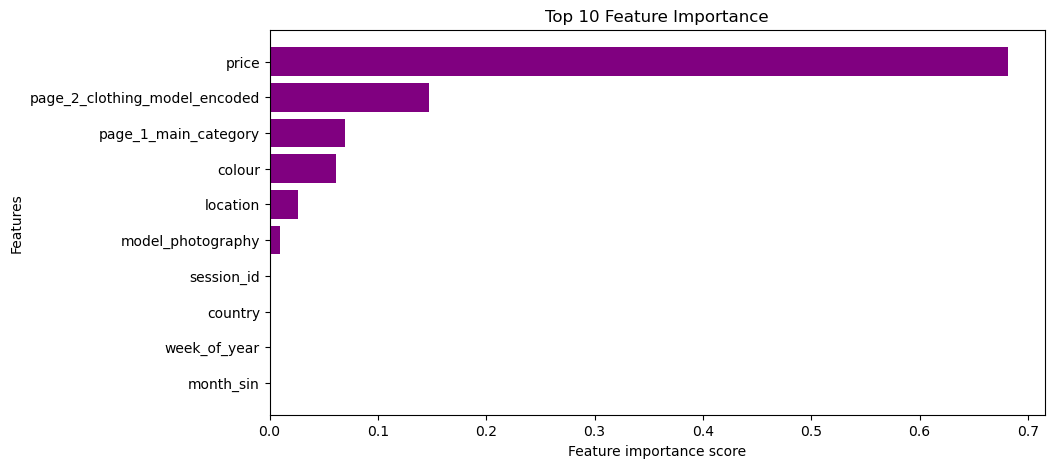

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
plt.barh(feature_important_df['featuers'][:10],
         feature_important_df['importance'][:10],
         color='purple')
plt.xlabel("Feature importance score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [46]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original,location_orignal,page_2_clothing_model_encoded,weekday_name_endcode
0,2008,4,1,1,29,1,1,A13,1,5,...,0.62349,0,Low,Poland,0,trousers,beige,bottom in the middle,4,5
1,2008,4,1,2,29,1,1,A16,1,6,...,0.62349,0,Low,Poland,0,trousers,beige,bottom right,7,5
2,2008,4,1,3,29,1,2,B4,10,2,...,0.62349,0,Low,Poland,0,skirts,olive,top in the middle,70,5
3,2008,4,1,4,29,1,2,B17,6,6,...,0.62349,0,Low,Poland,0,skirts,gray,bottom right,51,5
4,2008,4,1,5,29,1,2,B8,4,3,...,0.62349,0,Low,Poland,0,skirts,brown,top right,74,5


In [47]:
rg_model = RandomForestRegressor(n_estimators=400,random_state=42)
reg_x = df[selected_cols[:-1]]
reg_y = df['price']

In [48]:
reg_x

,day_of_week,weekday_name_endcode,is_weekend,week_of_year,quarter,is_month_start,is_month_end,month_sin,month_cos,dayofweek_sin,dayofweek_cos,is_holiday,country,session_id,page_1_main_category,page_2_clothing_model_encoded,colour,location,model_photography
0,1,5,0,14,2,1,0,0.866025,-0.5,0.781831,0.623490,0,29,1,1,4,1,5,1
1,1,5,0,14,2,1,0,0.866025,-0.5,0.781831,0.623490,0,29,1,1,7,1,6,1
2,1,5,0,14,2,1,0,0.866025,-0.5,0.781831,0.623490,0,29,1,2,70,10,2,1
3,1,5,0,14,2,1,0,0.866025,-0.5,0.781831,0.623490,0,29,1,2,51,6,6,2
4,1,5,0,14,2,1,0,0.866025,-0.5,0.781831,0.623490,0,29,1,2,74,4,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165469,2,6,0,33,3,0,0,-0.866025,-0.5,0.974928,-0.222521,0,29,24024,2,44,2,4,1
165470,2,6,0,33,3,0,0,-0.866025,-0.5,0.974928,-0.222521,0,9,24025,1,2,3,4,1
165471,2,6,0,33,3,0,0,-0.866025,-0.5,0.974928,-0.222521,0,34,24026,1,11,3,1,1
165472,2,6,0,33,3,0,0,-0.866025,-0.5,0.974928,-0.222521,0,34,24026,3,87,12,1,1


In [49]:
rg_model.fit(reg_x,reg_y)

RandomForestRegressor(n_estimators=400, random_state=42)

In [50]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original,location_orignal,page_2_clothing_model_encoded,weekday_name_endcode
0,2008,4,1,1,29,1,1,A13,1,5,...,0.62349,0,Low,Poland,0,trousers,beige,bottom in the middle,4,5
1,2008,4,1,2,29,1,1,A16,1,6,...,0.62349,0,Low,Poland,0,trousers,beige,bottom right,7,5
2,2008,4,1,3,29,1,2,B4,10,2,...,0.62349,0,Low,Poland,0,skirts,olive,top in the middle,70,5
3,2008,4,1,4,29,1,2,B17,6,6,...,0.62349,0,Low,Poland,0,skirts,gray,bottom right,51,5
4,2008,4,1,5,29,1,2,B8,4,3,...,0.62349,0,Low,Poland,0,skirts,brown,top right,74,5


In [51]:
reg_feature_importance_df = pd.DataFrame({
    "features":reg_x.columns,
    "importance":rg_model.feature_importances_
})

In [52]:
reg_feature_importance_df.sort_values(by="importance",ascending=False,inplace=True)

In [53]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original,location_orignal,page_2_clothing_model_encoded,weekday_name_endcode
0,2008,4,1,1,29,1,1,A13,1,5,...,0.62349,0,Low,Poland,0,trousers,beige,bottom in the middle,4,5
1,2008,4,1,2,29,1,1,A16,1,6,...,0.62349,0,Low,Poland,0,trousers,beige,bottom right,7,5
2,2008,4,1,3,29,1,2,B4,10,2,...,0.62349,0,Low,Poland,0,skirts,olive,top in the middle,70,5
3,2008,4,1,4,29,1,2,B17,6,6,...,0.62349,0,Low,Poland,0,skirts,gray,bottom right,51,5
4,2008,4,1,5,29,1,2,B8,4,3,...,0.62349,0,Low,Poland,0,skirts,brown,top right,74,5


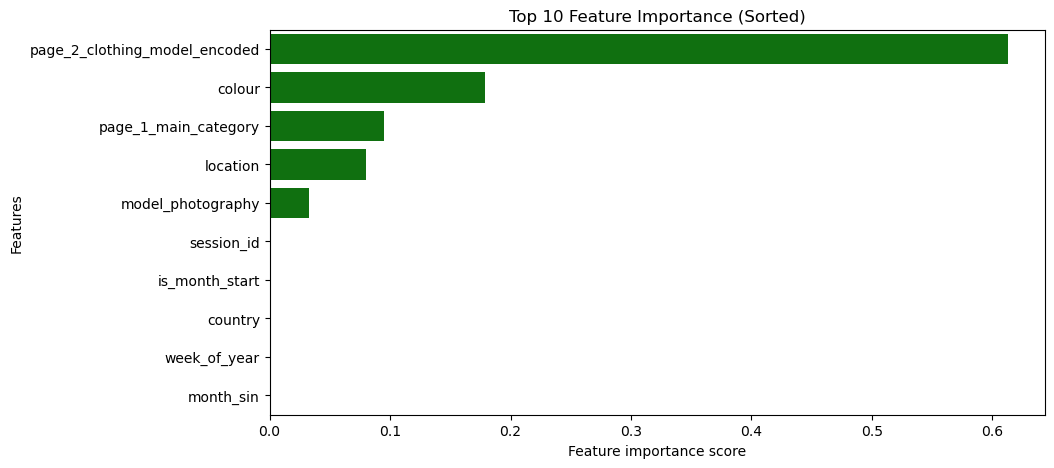

In [54]:
top_features_df = reg_feature_importance_df.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_features_df['importance'], y=top_features_df['features'], color="green")
plt.xlabel("Feature importance score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance (Sorted)")
plt.show()

In [55]:
df.head()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,...,dayofweek_cos,is_holiday,order_level,country_original,order_level_encoded,page_1_main_category_orignal,colour_original,location_orignal,page_2_clothing_model_encoded,weekday_name_endcode
0,2008,4,1,1,29,1,1,A13,1,5,...,0.62349,0,Low,Poland,0,trousers,beige,bottom in the middle,4,5
1,2008,4,1,2,29,1,1,A16,1,6,...,0.62349,0,Low,Poland,0,trousers,beige,bottom right,7,5
2,2008,4,1,3,29,1,2,B4,10,2,...,0.62349,0,Low,Poland,0,skirts,olive,top in the middle,70,5
3,2008,4,1,4,29,1,2,B17,6,6,...,0.62349,0,Low,Poland,0,skirts,gray,bottom right,51,5
4,2008,4,1,5,29,1,2,B8,4,3,...,0.62349,0,Low,Poland,0,skirts,brown,top right,74,5


In [56]:
regression_important_cols =[
    "page_2_clothing_model",
    "colour",
    "page_1_main_category",
    "location",
    "model_photography",
    "session_id",
    "country",
    "date",
    'order_level',
    "price"
]
classification_important_cols =[
    "page_2_clothing_model",
    "colour",
    "page_1_main_category",
    "location", 
    "model_photography",
    "session_id",
    "country",
    "date",
    'order_level',
    "price_2"
]

In [57]:
df[regression_important_cols].to_csv("reggession_clean_data.csv",index=False)
df[classification_important_cols].to_csv("classification_clean_data.csv",index=False)